# resistance detection


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import find_peaks

In [3]:
PROJECT_ROOT = Path('__file__').resolve().parent.parent
csv_path = PROJECT_ROOT / "data" / "processed_stock_data.csv" # setting the csv raw file path
csv_path

WindowsPath('D:/IndianStockMarketAnalysis/data/processed_stock_data.csv')

In [4]:
df = pd.read_csv(csv_path)
df["Date"] = pd.to_datetime(df["Date"])

df.head()

,Date,Close,High,Low,Open,Volume,Stock,Return,MA20,MA50,Volatility,RSI,MACD,Trend
0,2025-03-20,872.580322,875.170313,862.985046,865.303681,17833978,HDFC BANK,NaN,NaN,NaN,NaN,NaN,NaN,Sideways
1,2025-03-21,873.369690,875.219684,866.068418,866.068418,33508264,HDFC BANK,0.000905,NaN,NaN,NaN,NaN,NaN,Sideways
2,2025-03-24,887.996948,890.167619,874.997672,877.636984,17393736,HDFC BANK,0.016748,NaN,NaN,NaN,NaN,NaN,Sideways
3,2025-03-25,898.578918,909.555548,888.736976,890.414316,39101416,HDFC BANK,0.011917,NaN,NaN,NaN,NaN,NaN,Sideways
4,2025-03-26,891.228333,901.563607,888.983649,900.330278,24478442,HDFC BANK,-0.008180,NaN,NaN,NaN,NaN,NaN,Sideways


In [5]:
stock_df = df[df["Stock"] == "RELIANCE"].copy()

stock_df = stock_df.sort_values("Date")
stock_df = stock_df.reset_index(drop=True)

In [6]:
peaks, _ = find_peaks(stock_df["Close"], distance=20)

resistance_levels = stock_df.iloc[peaks]["Close"]
resistance_levels.head()

2      1296.920166
36     1450.606445
72     1535.367920
104    1424.800049
144    1466.800049
Name: Close, dtype: float64

In [7]:
lows, _ = find_peaks(-stock_df["Close"], distance=20)

support_levels = stock_df.iloc[lows]["Close"]
support_levels.head()

11     1161.062744
31     1371.721436
56     1422.219849
87     1382.080078
110    1353.900024
Name: Close, dtype: float64

In [8]:
resistance_levels = resistance_levels.sort_values(ascending=False).head(2)

support_levels = support_levels.sort_values().head(2)

print("Resistance:", resistance_levels.values)
print("Support:", support_levels.values)

Resistance: [1592.30004883 1569.90002441]
Support: [1161.06274414 1345.        ]


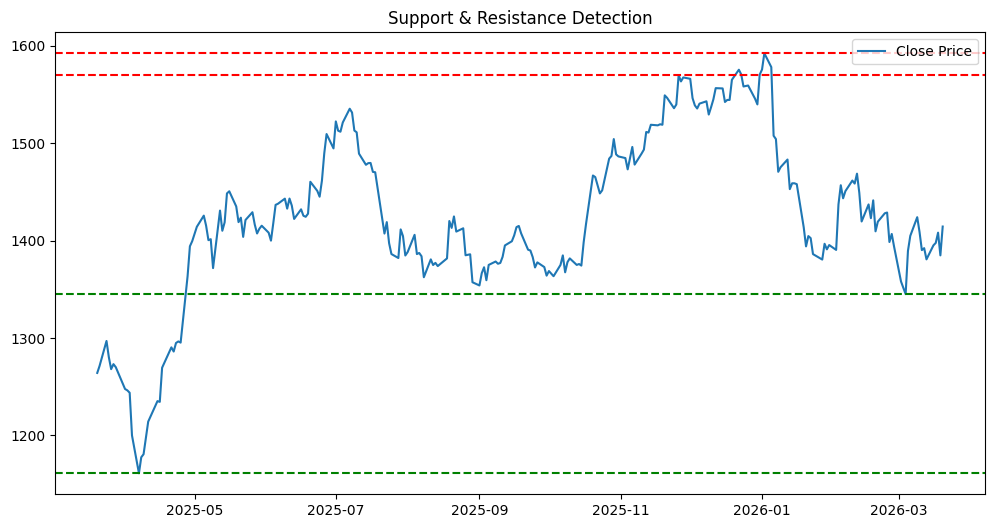

In [11]:
plt.figure(figsize=(12,6))

plt.plot(stock_df["Date"], stock_df["Close"], label="Close Price")

for r in resistance_levels:
    plt.axhline(r, color="red", linestyle="--")

for s in support_levels:
    plt.axhline(s, color="green", linestyle="--")

plt.title("Support & Resistance Detection")
plt.legend()

plt.show()

In [12]:
def get_support_resistance(data):

    data = data.sort_values("Date")

    peaks, _ = find_peaks(data["Close"], distance=20)
    lows, _ = find_peaks(-data["Close"], distance=20)

    resistance = data.iloc[peaks]["Close"].sort_values(ascending=False).head(2)
    support = data.iloc[lows]["Close"].sort_values().head(2)

    return support.values, resistance.values

In [13]:
s, r = get_support_resistance(stock_df)

print(s, r)

[1161.06274414 1345.        ] [1592.30004883 1569.90002441]


In [15]:
levels_data = []

for stock in df["Stock"].unique():
    
    temp = df[df["Stock"] == stock]
    
    s, r = get_support_resistance(temp)
    
    levels_data.append({
        "Stock": stock,
        "Support1": s[0] if len(s)>0 else np.nan,
        "Support2": s[1] if len(s)>1 else np.nan,
        "Resistance1": r[0] if len(r)>0 else np.nan,
        "Resistance2": r[1] if len(r)>1 else np.nan
    })

levels_df = pd.DataFrame(levels_data)
save_path = PROJECT_ROOT / "data" / "support_resistance_levels.csv"
levels_df.to_csv(save_path, index=False)